## This Notebook ...


# Load and aggregate the experimental data

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd

project_root = Path("/home/dwp46550/ba_nylon")

df = pd.read_csv(
    project_root / "matrices" / "NylC_Puetz_raw_data.CSV",
    sep=";",
    decimal=","
)

# Identify the replicate columns introduced in the revised raw-data table.
activity_rep_cols = [
    col for col in df.columns
    if col.startswith("activity_pa6_")
]

tm_rep_cols = [
    col for col in df.columns
    if col.startswith("tm_celsius_")
]

if not activity_rep_cols:
    raise ValueError("No PA6 activity replicate columns were found.")

if not tm_rep_cols:
    raise ValueError("No melting-temperature replicate columns were found.")

# Convert all replicate measurements to numeric values. Missing measurements
# remain NaN and are excluded from the variant-level aggregation.
df[activity_rep_cols + tm_rep_cols] = df[
    activity_rep_cols + tm_rep_cols
].apply(pd.to_numeric, errors="coerce")

# Aggregate PA6 activity replicates. The column activity_pa6 is retained as
# the variant-level mean used by the exploratory plots and later models.
df["activity_n"] = df[activity_rep_cols].count(axis=1)
df["activity_pa6"] = df[activity_rep_cols].mean(axis=1, skipna=True)
df["activity_sd"] = df[activity_rep_cols].std(axis=1, skipna=True, ddof=1)
df["activity_sem"] = df["activity_sd"] / np.sqrt(df["activity_n"])

# Aggregate melting-temperature replicates in the same way.
df["tm_n"] = df[tm_rep_cols].count(axis=1)
df["tm_celsius"] = df[tm_rep_cols].mean(axis=1, skipna=True)
df["tm_sd"] = df[tm_rep_cols].std(axis=1, skipna=True, ddof=1)
df["tm_sem"] = df["tm_sd"] / np.sqrt(df["tm_n"])

print("Activity replicate columns:", activity_rep_cols)
print("Tm replicate columns:", tm_rep_cols)
print("Loaded and aggregated variants:", len(df))

In [9]:
print(df.shape)

print("\nmissing values:")
print(df.isna().sum())

print("\ndatatype:")
print(df.dtypes)

print("\nmost active variant:")
print(
    df.sort_values("activity_pa6", ascending=False)[
        ["variant_id", "activity_pa6", "tm_celsius"]
    ].head(10)
)

(36, 7)

missing values:
variant_id        0
variant_class     0
mutations         1
n_mutations       0
activity_pa6      0
tm_celsius        3
structure_file    0
dtype: int64

datatype:
variant_id         object
variant_class      object
mutations          object
n_mutations         int64
activity_pa6        int64
tm_celsius        float64
structure_file     object
dtype: object

most active variant:
                variant_id  activity_pa6  tm_celsius
28       F134W_D304M_R330A           520        89.9
15             F134W_D304M           410        89.9
31  D99G_F134W_D304M_R330A           410        87.6
24        D99R_F134W_R330A           406         NaN
32  D99V_F134W_D304M_R330A           391        84.8
29       F134W_D304M_R330Q           372        89.8
16             F134W_D304L           371        90.4
17             F134W_D304I           341        90.2
30  D99R_F134W_D304M_R330A           296        90.2
26        D99G_F134W_D304M           266        83.7


<Figure size 600x400 with 0 Axes>

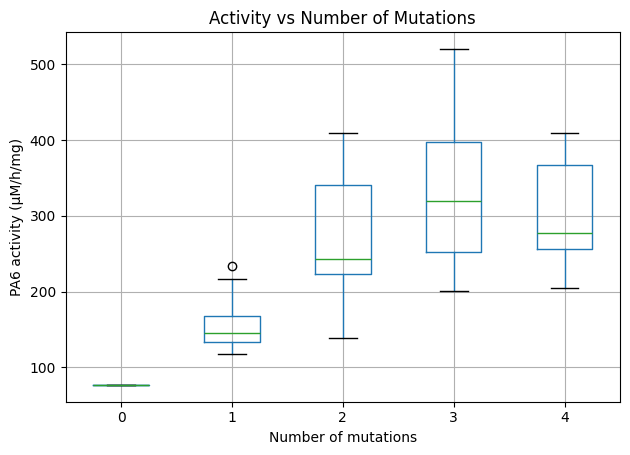

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df.boxplot(column="activity_pa6", by="n_mutations")

plt.title("Activity vs Number of Mutations")
plt.suptitle("")
plt.xlabel("Number of mutations")
plt.ylabel("PA6 activity (µM/h/mg)")
plt.tight_layout()
plt.show()

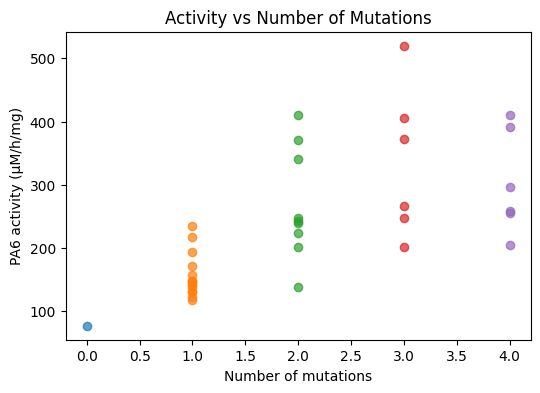

In [11]:
plt.figure(figsize=(6,4))

for n in sorted(df["n_mutations"].unique()):
    subset = df[df["n_mutations"] == n]
    plt.scatter(
        [n]*len(subset),
        subset["activity_pa6"],
        alpha=0.7
    )

plt.xlabel("Number of mutations")
plt.ylabel("PA6 activity (µM/h/mg)")
plt.title("Activity vs Number of Mutations")
plt.show()

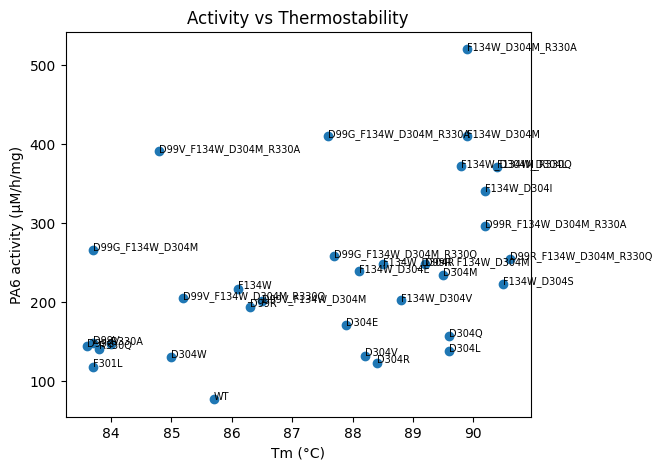

Pearson correlation: 0.454


In [13]:
plt.figure(figsize=(6,5))

plt.scatter(
    df["tm_celsius"],
    df["activity_pa6"]
)

for _, row in df.iterrows():
    plt.annotate(
        row["variant_id"],
        (row["tm_celsius"], row["activity_pa6"]),
        fontsize=7
    )

plt.xlabel("Tm (°C)")
plt.ylabel("PA6 activity (µM/h/mg)")
plt.title("Activity vs Thermostability")
plt.show()
corr = df["activity_pa6"].corr(df["tm_celsius"])

print(f"Pearson correlation: {corr:.3f}")

In [14]:
def mutation_family(x):

    if pd.isna(x):
        return "WT"

    if "D99" in x:
        return "D99"

    if "F134" in x:
        return "F134"

    if "D304" in x:
        return "D304"

    if "R330" in x:
        return "R330"

    return "Other"

df["mutation_family"] = df["mutations"].apply(mutation_family)

<Figure size 800x400 with 0 Axes>

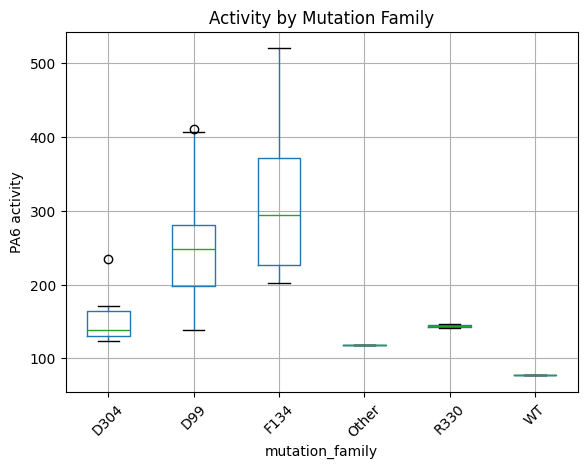

<Figure size 800x400 with 0 Axes>

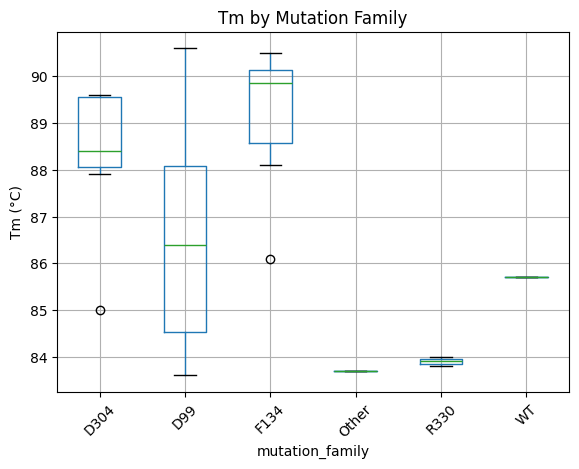

In [15]:
plt.figure(figsize=(8,4))

df.boxplot(
    column="activity_pa6",
    by="mutation_family",
    rot=45
)

plt.title("Activity by Mutation Family")
plt.suptitle("")
plt.ylabel("PA6 activity")
plt.show()

plt.figure(figsize=(8,4))

df.boxplot(
    column="tm_celsius",
    by="mutation_family",
    rot=45
)

plt.title("Tm by Mutation Family")
plt.suptitle("")
plt.ylabel("Tm (°C)")
plt.show()

In [18]:
import pandas as pd

pivot = df.pivot_table(
    values="activity_pa6",
    index="n_mutations",
    aggfunc=["mean","std","count"]
)

print(pivot)

                    mean          std        count
            activity_pa6 activity_pa6 activity_pa6
n_mutations                                       
0              77.000000          NaN            1
1             156.714286    35.181788           14
2             268.444444    87.312816            9
3             335.500000   119.096180            6
4             302.500000    81.453668            6
